<a href="https://colab.research.google.com/github/talitharhmd/Tugas-Akhir/blob/main/LDA_Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Langsung dari Hasil LDA (Tanpa Embedding & Reduksi Dimensi)

Notebook ini melakukan **K-Means Clustering langsung pada distribusi probabilitas topik hasil LDA terbaik**, tanpa melalui tahap word embedding (Word2Vec/FastText/Fast2Vec) maupun reduksi dimensi (PCA/UMAP).

Skenario ini berbeda dari notebook `LDA_Embedding_Cluster`, dan dibuat sesuai arahan dosen pembimbing untuk melihat performa clustering apabila **hanya fitur LDA saja** yang digunakan, tanpa fitur tambahan dari embedding.

Notebook ini membandingkan **dua skenario praproses fitur** sebelum clustering:
- **Dengan Scaler** — fitur distribusi topik distandarisasi memakai `StandardScaler`
- **Tanpa Scaler** — fitur distribusi topik dipakai langsung (nilai probabilitas asli LDA, sudah berskala 0–1)

**Alur kerja notebook:**
1. Import library & load data hasil LDA terbaik
2. Persiapan fitur clustering (dengan scaler & tanpa scaler)
3. Pencarian k optimal (k=2 sampai k=10) untuk kedua skenario, berdasarkan Silhouette, Elbow, dan Davies-Bouldin Index (DBI)
4. Clustering final menggunakan k terbaik per metode, untuk kedua skenario
5. Visualisasi hasil clustering (2D, 3D statis, 3D interaktif)
6. Interpretasi cluster: c-TF-IDF, Coherence Score, Silhouette per cluster
7. Perbandingan akhir: skenario mana (dengan/tanpa scaler) yang lebih baik
8. Penyimpanan seluruh hasil (tabel & gambar) ke struktur folder yang rapi untuk diunggah ke GitHub


## 1. Import Library

Seluruh dependency yang dibutuhkan untuk clustering, evaluasi, dan visualisasi diimpor di satu tempat di awal notebook.

**Catatan:** notebook ini **tidak** memerlukan `gensim` untuk embedding, `umap-learn`, maupun `sklearn.decomposition.PCA`, karena tidak ada tahap embedding atau reduksi dimensi. `gensim` tetap dipakai sebatas untuk menghitung Coherence Score pada interpretasi cluster.


In [1]:
!pip install openpyxl -q
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.8 MB/s eta 0:00:00


In [2]:
import os
import ast
import warnings
import numpy as np
import pandas as pd

# --- Visualisasi ---
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display

# --- Clustering & evaluasi ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# --- Coherence Score (interpretasi kualitas cluster) ---
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

warnings.filterwarnings("ignore")
print("✔ semua library berhasil diimport")

✔ semua library berhasil diimport


### 1.1 Konstanta Global

- `ROUND_DIGIT` — jumlah angka desimal pembulatan untuk seluruh metrik evaluasi (Silhouette, DBI, Inertia, Coherence)
- `BASE_DIR` — folder utama tempat seluruh hasil (tabel & gambar) disimpan, disusun rapi per skenario agar mudah diunggah ke GitHub


In [3]:
ROUND_DIGIT = 3   # pembulatan seluruh metrik evaluasi

BASE_DIR = "hasil/lda_only"

FOLDERS = {
    "with_scaler": os.path.join(BASE_DIR, "with_scaler"),
    "no_scaler": os.path.join(BASE_DIR, "no_scaler"),
}

for path in FOLDERS.values():
    os.makedirs(os.path.join(path, "grafik"), exist_ok=True)

print("Struktur folder yang dibuat:")
for name, path in FOLDERS.items():
    print(f"  [{name}] -> {path}/grafik/")

Struktur folder yang dibuat:
  [with_scaler] -> hasil/lda_only/with_scaler/grafik/
  [no_scaler] -> hasil/lda_only/no_scaler/grafik/


## 2. Load Data Hasil LDA Terbaik

Dataset yang dipakai adalah hasil keluaran model LDA terbaik (skenario **Lematisasi**, `no_below=5`, `no_above=0.6`, **k=4**, `coherence=0.621`) yang sudah memuat kolom distribusi probabilitas topik (`topic_1` ... `topic_4`) dan label topik dominan.

Kolom `lemma_text` disimpan dalam file CSV sebagai **string representasi list** (misal `"['forecasting', 'series', 'model']"`), bukan list Python asli maupun kalimat biasa. Kolom ini perlu dikonversi balik menjadi list token menggunakan `ast.literal_eval` sebelum dipakai untuk c-TF-IDF dan Coherence Score — tahap inilah yang sebelumnya terlewat dan menyebabkan error `unable to interpret topic as either a list of tokens or a list of ids` pada perhitungan Coherence Score.


In [4]:
df = pd.read_excel('/content/lematisasi_nb5_na0.6_k4_dataset_new.xlsx')
df.insert(0, "doc_id", range(1, len(df) + 1))

print("Ukuran data :", df.shape)
print("Kolom       :", list(df.columns))
df.head()

Ukuran data : (3326, 11)
Kolom       : ['doc_id', 'Year', 'clean_text', 'lemma_text', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topik_dominan', 'probabilitas_topik', 'label_topik']


,doc_id,Year,clean_text,lemma_text,topic_1,topic_2,topic_3,topic_4,topik_dominan,probabilitas_topik,label_topik
0,1,2020,multivariate series forecasting mtsf has recen...,"['multivariate', 'series', 'forecasting', 'mts...",0.996744,0.001075,0.001325,0.000856,1,0.996744,Forecasting Time Series
1,2,2020,traditional series forecasting techniques can ...,"['traditional', 'series', 'forecasting', 'tech...",0.996313,0.001218,0.001499,0.000970,1,0.996313,Forecasting Time Series
2,3,2020,recent approaches to series forecasting especi...,"['approach', 'series', 'forecasting', 'especia...",0.995919,0.001347,0.001660,0.001073,1,0.995919,Forecasting Time Series
3,4,2020,sea surface height anomaly ssha is an elementa...,"['sea', 'surface', 'height', 'anomaly', 'ssha'...",0.995873,0.001364,0.001679,0.001085,1,0.995873,Forecasting Time Series
4,5,2020,generalized autoregressive conditional heteros...,"['generalized', 'autoregressive', 'conditional...",0.995382,0.001524,0.001879,0.001215,1,0.995382,Forecasting Time Series


In [5]:
def fix_format(text):
    """Mengubah string representasi list (misal "['kata1','kata2']") menjadi list Python asli."""
    if isinstance(text, list):
        return text
    if isinstance(text, str) and text.strip().startswith('['):
        try:
            return ast.literal_eval(text)
        except Exception:
            return text.split()
    if isinstance(text, str):
        return text.split()
    return []


# lemma_text dikonversi balik menjadi list token, lalu disimpan juga versi
# string kalimat (dipisah spasi) untuk keperluan CountVectorizer pada c-TF-IDF
df["lemma_tokens"] = df["lemma_text"].apply(fix_format)
df["lemma_text"] = df["lemma_tokens"].apply(lambda toks: " ".join(toks))

print("Contoh lemma_tokens :", df["lemma_tokens"].iloc[0][:8])
print("Contoh lemma_text   :", df["lemma_text"].iloc[0][:80])

Contoh lemma_tokens : ['multivariate', 'series', 'forecasting', 'mtsf', 'emerged', 'growing', 'importance', 'industry']
Contoh lemma_text   : multivariate series forecasting mtsf emerged growing importance industry however


## 3. Persiapan Fitur untuk Clustering: Dengan Scaler vs Tanpa Scaler

Fitur clustering pada skenario ini **hanya berasal dari distribusi probabilitas topik LDA** (kolom `topic_1` sampai `topic_k`) — tidak digabung dengan vektor embedding apa pun.

Dua versi fitur disiapkan untuk dibandingkan:
- **`X_with_scaler`** — fitur distandarisasi dengan `StandardScaler` (mean=0, std=1), seperti pendekatan umum sebelum K-Means
- **`X_no_scaler`** — fitur dipakai langsung tanpa standarisasi

Standarisasi biasanya penting ketika fitur memiliki skala berbeda jauh (misal menggabungkan embedding dengan probabilitas topik). Namun karena di sini **seluruh fitur sudah berada pada skala yang sama** (probabilitas topik LDA, rentang 0–1), pengaruh `StandardScaler` kemungkinan tidak akan sebesar saat menggabungkan fitur embedding + LDA. Perbandingan ini dilakukan untuk membuktikan hal tersebut secara empiris, bukan berdasarkan asumsi semata.


In [6]:
KOLOM_META = ["doc_id", "Year", "clean_text", "lemma_text", "lemma_tokens",
              "topik_dominan", "probabilitas_topik", "label_topik"]

kolom_fitur_lda = [c for c in df.columns if c.startswith("topic_")]

print(f"Jumlah fitur topik LDA : {len(kolom_fitur_lda)}")
print(f"Kolom fitur            : {kolom_fitur_lda}")

X_raw = df[kolom_fitur_lda].values

# Skenario 1: dengan StandardScaler
X_with_scaler = StandardScaler().fit_transform(X_raw)

# Skenario 2: tanpa scaler (probabilitas topik asli)
X_no_scaler = X_raw.copy()

print(f"\nDimensi fitur (with_scaler) : {X_with_scaler.shape}")
print(f"Dimensi fitur (no_scaler)   : {X_no_scaler.shape}")

print("\nContoh statistik kolom topic_1:")
print(f"  Raw (no_scaler)   -> mean={round(X_no_scaler[:, 0].mean(), ROUND_DIGIT)}, "
      f"std={round(X_no_scaler[:, 0].std(), ROUND_DIGIT)}")
print(f"  Scaled (with_scaler) -> mean={round(X_with_scaler[:, 0].mean(), ROUND_DIGIT)}, "
      f"std={round(X_with_scaler[:, 0].std(), ROUND_DIGIT)}")

DATASETS = {
    "with_scaler": X_with_scaler,
    "no_scaler": X_no_scaler,
}

Jumlah fitur topik LDA : 4
Kolom fitur            : ['topic_1', 'topic_2', 'topic_3', 'topic_4']

Dimensi fitur (with_scaler) : (3326, 4)
Dimensi fitur (no_scaler)   : (3326, 4)

Contoh statistik kolom topic_1:
  Raw (no_scaler)   -> mean=0.2, std=0.287
  Scaled (with_scaler) -> mean=-0.0, std=1.0


## 4. Fungsi Bantu Evaluasi & Visualisasi Cluster

Fungsi-fungsi berikut digunakan berulang kali pada tahap pencarian k optimal dan interpretasi hasil cluster, untuk **kedua skenario** (dengan scaler & tanpa scaler):
- `compute_best_k` — menentukan k optimal berdasarkan 3 metode (Elbow, Silhouette, DBI)
- `decide_final_k` — menyatukan k jika ketiga metode sepakat, atau menyimpan k masing-masing jika berbeda
- `plot_evaluation` — memvisualisasikan ketiga metrik terhadap k
- `plot_cluster_2d` / `plot_cluster_3d_static` / `plot_cluster_3d_interactive` — visualisasi hasil cluster
- `extract_ctfidf` / `compute_coherence` — interpretasi kata kunci dominan tiap cluster
- `silhouette_per_cluster` — kualitas pemisahan tiap cluster secara individual


In [7]:
def compute_best_k(k_list, sil_list, dbi_list, inertia_list):
    """
    Mengembalikan dict berisi k terbaik dari tiga metode:
    elbow (rasio penurunan inertia), silhouette (maksimum), DBI (minimum).
    """
    delta = [inertia_list[i] - inertia_list[i + 1] for i in range(len(inertia_list) - 1)]
    ratio = [delta[i + 1] / delta[i] for i in range(len(delta) - 1)]
    elbow_idx = int(np.argmin(ratio)) + 1

    sil_idx = int(np.argmax(sil_list))
    dbi_idx = int(np.argmin(dbi_list))

    return {
        "elbow": {
            "k": k_list[elbow_idx], "inertia": inertia_list[elbow_idx],
            "sil": sil_list[elbow_idx], "dbi": dbi_list[elbow_idx],
        },
        "silhouette": {
            "k": k_list[sil_idx], "score": sil_list[sil_idx],
            "dbi": dbi_list[sil_idx], "inertia": inertia_list[sil_idx],
        },
        "dbi": {
            "k": k_list[dbi_idx], "score": dbi_list[dbi_idx],
            "sil": sil_list[dbi_idx], "inertia": inertia_list[dbi_idx],
        },
        "delta_inertia": delta,
    }


def print_best_k_summary(name, best):
    """Cetak ringkasan hasil tiga metode pemilihan k."""
    print("=" * 60)
    print(f"  BEST EXPERIMENT : {name}")
    print("=" * 60)

    print("\nHASIL BERDASARKAN SILHOUETTE")
    print("-" * 40)
    print(f"  K optimal   : {best['silhouette']['k']}")
    print(f"  Silhouette  : {round(best['silhouette']['score'], ROUND_DIGIT)}")
    print(f"  DBI         : {round(best['silhouette']['dbi'], ROUND_DIGIT)}")
    print(f"  Inertia     : {round(best['silhouette']['inertia'], ROUND_DIGIT)}")

    print("\nHASIL BERDASARKAN ELBOW")
    print("-" * 40)
    print(f"  K optimal   : {best['elbow']['k']}")
    print(f"  Inertia     : {round(best['elbow']['inertia'], ROUND_DIGIT)}")
    print(f"  Silhouette  : {round(best['elbow']['sil'], ROUND_DIGIT)}")
    print(f"  DBI         : {round(best['elbow']['dbi'], ROUND_DIGIT)}")

    print("\nHASIL BERDASARKAN DBI")
    print("-" * 40)
    print(f"  K optimal   : {best['dbi']['k']}")
    print(f"  DBI         : {round(best['dbi']['score'], ROUND_DIGIT)}")
    print(f"  Silhouette  : {round(best['dbi']['sil'], ROUND_DIGIT)}")
    print(f"  Inertia     : {round(best['dbi']['inertia'], ROUND_DIGIT)}")


def decide_final_k(best):
    """
    Jika ketiga metode menghasilkan k yang sama -> pakai k tersebut untuk ketiganya.
    Jika berbeda -> kembalikan k masing-masing metode secara terpisah.
    """
    k_sil, k_elbow, k_dbi = best["silhouette"]["k"], best["elbow"]["k"], best["dbi"]["k"]
    unique_k = set([k_sil, k_elbow, k_dbi])

    if len(unique_k) == 1:
        print(f"✔ Semua metode sepakat: K={k_sil} -> pakai SILHOUETTE")
        return {"mode": "UNIFIED", "sil": k_sil, "elbow": k_sil, "dbi": k_sil}
    else:
        print(f"⚠ K berbeda: Sil={k_sil}, Elbow={k_elbow}, DBI={k_dbi} -> simpan semua")
        return {"mode": "MULTI", "sil": k_sil, "elbow": k_elbow, "dbi": k_dbi}


def cluster_with_k(X, k):
    """Menjalankan K-Means untuk k tertentu, mengembalikan label cluster dan posisi centroid."""
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(X)
    return labels, model.cluster_centers_

In [8]:
COLOR_LINE = "#1565C0"
COLOR_MARK = "#E53935"
COLOR_SIL  = "#2E7D32"
COLOR_DBI  = "#F57F17"


def plot_evaluation(k_list, sil_list, dbi_list, inertia_list, best, scenario_name, save_dir):
    """Plot tiga panel evaluasi: Elbow, Silhouette, dan DBI terhadap k. Selalu disimpan ke save_dir."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Evaluasi Clustering — {scenario_name}", fontsize=14, fontweight="bold")

    k_elbow, k_sil, k_dbi = best["elbow"]["k"], best["silhouette"]["k"], best["dbi"]["k"]

    # Elbow
    ax = axes[0]
    ax.plot(k_list, inertia_list, marker='o', linewidth=2, color=COLOR_LINE)
    for x, y in zip(k_list, inertia_list):
        ax.annotate(f"{round(y, ROUND_DIGIT)}", (x, y), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7.5)
    ax.scatter(k_elbow, best["elbow"]["inertia"], s=220, color=COLOR_MARK, zorder=5,
               label=f"Elbow K={k_elbow}")
    ax.annotate(f"Elbow\nK={k_elbow}", (k_elbow, best["elbow"]["inertia"]),
                textcoords="offset points", xytext=(12, -20), fontsize=9, color=COLOR_MARK,
                arrowprops=dict(arrowstyle="->", color=COLOR_MARK))
    ax.set_title("Elbow Method", fontsize=11, fontweight="bold")
    ax.set_xlabel("Jumlah Cluster (K)"); ax.set_ylabel("Inertia")
    ax.set_xticks(k_list); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # Silhouette
    ax = axes[1]
    ax.plot(k_list, sil_list, marker='s', linewidth=2, color=COLOR_SIL)
    for x, y in zip(k_list, sil_list):
        ax.annotate(f"{round(y, ROUND_DIGIT)}", (x, y), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7.5)
    ax.scatter(k_sil, best["silhouette"]["score"], s=220, marker='*', color=COLOR_MARK, zorder=5,
               label=f"Best K={k_sil} ({round(best['silhouette']['score'], ROUND_DIGIT)})")
    ax.annotate(f"Best\nK={k_sil}", (k_sil, best["silhouette"]["score"]),
                textcoords="offset points", xytext=(12, -18), fontsize=9, color=COLOR_MARK,
                arrowprops=dict(arrowstyle="->", color=COLOR_MARK))
    ax.set_title("Silhouette Score\n(makin tinggi = makin baik)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Jumlah Cluster (K)"); ax.set_ylabel("Silhouette Score")
    ax.set_xticks(k_list); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # DBI
    ax = axes[2]
    ax.plot(k_list, dbi_list, marker='^', linewidth=2, color=COLOR_DBI)
    for x, y in zip(k_list, dbi_list):
        ax.annotate(f"{round(y, ROUND_DIGIT)}", (x, y), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7.5)
    ax.scatter(k_dbi, best["dbi"]["score"], s=220, marker='*', color=COLOR_MARK, zorder=5,
               label=f"Best K={k_dbi} ({round(best['dbi']['score'], ROUND_DIGIT)})")
    ax.annotate(f"Best\nK={k_dbi}", (k_dbi, best["dbi"]["score"]),
                textcoords="offset points", xytext=(12, 10), fontsize=9, color=COLOR_MARK,
                arrowprops=dict(arrowstyle="->", color=COLOR_MARK))
    ax.set_title("DBI\n(makin kecil = makin baik)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Jumlah Cluster (K)"); ax.set_ylabel("DBI Score")
    ax.set_xticks(k_list); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(save_dir, f"eval_{scenario_name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✔ Grafik evaluasi disimpan: {path}")

In [9]:
def plot_cluster_2d(X, labels, centroids, title, save_path=None):
    """Scatter 2D dengan centroid ditandai bintang."""
    unique_labels = np.unique(labels)
    colors = cm.tab10(np.linspace(0, 1, len(unique_labels)))

    plt.figure(figsize=(8, 6))
    for i, c in enumerate(unique_labels):
        mask = labels == c
        plt.scatter(X[mask, 0], X[mask, 1], s=12, alpha=0.6, color=colors[i], label=f"Cluster {c}")
        plt.scatter(centroids[i, 0], centroids[i, 1], s=280, marker="*",
                    color=colors[i], edgecolor="black", linewidths=0.8)

    plt.title(title, fontweight="bold")
    plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
    plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✔ 2D plot disimpan: {save_path}")
    plt.show()


def plot_cluster_3d_static(X, labels, centroids, title, save_path=None):
    """Scatter 3D statis (matplotlib). Membutuhkan minimal 3 dimensi fitur."""
    if X.shape[1] < 3:
        print("⚠ Butuh minimal 3 dimensi untuk plot 3D.")
        return

    unique_labels = np.unique(labels)
    colors = cm.tab10(np.linspace(0, 1, len(unique_labels)))

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    for i, c in enumerate(unique_labels):
        mask = labels == c
        ax.scatter(X[mask, 0], X[mask, 1], X[mask, 2], s=12, alpha=0.5,
                   color=colors[i], label=f"Cluster {c}")
        ax.scatter(centroids[i, 0], centroids[i, 1], centroids[i, 2],
                   s=280, marker="*", color=colors[i], edgecolor="black")

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2"); ax.set_zlabel("Dim 3")
    ax.legend(fontsize=8)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✔ 3D static plot disimpan: {save_path}")
    plt.show()


def plot_cluster_3d_interactive(X, labels, centroids, title="Cluster 3D Interaktif"):
    """Scatter 3D interaktif (Plotly). Membutuhkan minimal 3 dimensi fitur."""
    if X.shape[1] < 3:
        print("⚠ Butuh minimal 3 dimensi untuk plot 3D.")
        return

    fig = go.Figure()
    for i, c in enumerate(np.unique(labels)):
        mask = labels == c
        fig.add_trace(go.Scatter3d(
            x=X[mask, 0], y=X[mask, 1], z=X[mask, 2], mode="markers",
            marker=dict(size=3, opacity=0.6), name=f"Cluster {c}"
        ))
        fig.add_trace(go.Scatter3d(
            x=[centroids[i, 0]], y=[centroids[i, 1]], z=[centroids[i, 2]],
            mode="markers+text", marker=dict(size=9, symbol="diamond"),
            text=[f"C{c}"], textposition="top center", name=f"Centroid {c}"
        ))

    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="Dim 1", yaxis_title="Dim 2", zaxis_title="Dim 3"),
        margin=dict(l=0, r=0, b=0, t=40), height=700
    )
    fig.show()

In [10]:
def extract_ctfidf(df_cluster, text_col="lemma_text", top_n=10):
    """
    Menghitung c-TF-IDF (representasi kata kunci dominan per cluster).
    `text_col` harus berupa kolom STRING (kalimat dipisah spasi), bukan list token.

    token_pattern khusus dipakai agar kata bersambung garis bawah (misal
    "long_short_term_memory", "natural_language_processing") tidak ikut terpecah
    oleh tokenizer default CountVectorizer (yang hanya mengenali huruf sebagai token).

    Jika seluruh dokumen pada satu cluster ternyata hanya berisi stopword atau token
    yang tidak dikenali (vocabulary kosong), CountVectorizer akan gagal total kecuali
    `stop_words` dimatikan terlebih dahulu sebagai fallback, supaya proses tidak crash.

    Return DataFrame: cluster_id | keyword | ctfidf
    """
    docs = (df_cluster.groupby("cluster")[text_col]
            .apply(lambda x: " ".join(x.astype(str)))
            .reset_index())

    try:
        vec = CountVectorizer(stop_words="english", token_pattern=r"(?u)\b\w[\w_]+\b")
        X_ct = vec.fit_transform(docs[text_col])
    except ValueError:
        print("  ⚠ Vocabulary kosong dengan stop_words aktif -> mencoba tanpa stop_words")
        vec = CountVectorizer(stop_words=None, token_pattern=r"(?u)\b\w[\w_]+\b")
        X_ct = vec.fit_transform(docs[text_col])

    tfidf = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
    X_tf = tfidf.fit_transform(X_ct)
    terms = vec.get_feature_names_out()

    rows = []
    for i, cid in enumerate(docs["cluster"]):
        arr = X_tf[i].toarray()[0]
        n_available = min(top_n, len(terms))
        top_idx = arr.argsort()[-n_available:][::-1]
        for j in top_idx:
            rows.append({"cluster_id": cid, "keyword": terms[j],
                         "ctfidf": round(float(arr[j]), ROUND_DIGIT)})
    return pd.DataFrame(rows)


def compute_coherence(df_cluster, df_keyword, token_col="lemma_tokens"):
    """
    Menghitung Coherence Score (c_v) dari kata kunci dominan tiap cluster.
    `token_col` harus berupa kolom LIST token asli (bukan string), agar Dictionary
    dan CoherenceModel dapat mencocokkan kata kunci dengan token korpus dengan benar.

    Beberapa kata kunci hasil c-TF-IDF bisa jadi tidak persis cocok dengan token asli
    (beda tokenizer/stopword dari CountVectorizer), sehingga difilter dulu agar valid.
    Jika SEMUA kata kunci pada sebuah cluster tidak ditemukan di dictionary (topic kosong),
    Coherence Score tidak dapat dihitung untuk cluster tersebut dan diberi nilai NaN,
    alih-alih membuat seluruh proses gagal (gensim tidak menerima topic kosong).
    """
    texts = df_cluster[token_col].tolist()
    dictionary = Dictionary(texts)

    topics_per_cluster = [
        (cid, df_keyword[df_keyword["cluster_id"] == cid]["keyword"].tolist())
        for cid in sorted(df_keyword["cluster_id"].unique())
    ]

    valid_topics, valid_cids, empty_cids = [], [], []
    for cid, topic in topics_per_cluster:
        filtered = [w for w in topic if w in dictionary.token2id]
        if len(filtered) >= 2:   # minimal 2 kata agar coherence pairwise bisa dihitung
            valid_topics.append(filtered)
            valid_cids.append(cid)
        else:
            empty_cids.append(cid)

    if empty_cids:
        print(f"  ⚠ Cluster {empty_cids} dilewati saat hitung coherence "
              f"(kata kunci tidak cukup cocok dengan token corpus)")

    if not valid_topics:
        print("  ⚠ Tidak ada topic valid sama sekali -> Coherence Score = NaN")
        return float("nan")

    model = CoherenceModel(topics=valid_topics, texts=texts, dictionary=dictionary, coherence="c_v")
    return round(model.get_coherence(), ROUND_DIGIT)


def silhouette_per_cluster(X, labels):
    """
    Menghitung Silhouette Score rata-rata untuk setiap cluster secara individual.
    Return DataFrame: cluster_id | silhouette_per_cluster | jumlah_dokumen | persentase
    """
    sil_samples = silhouette_samples(X, labels)
    rows = []
    total = len(labels)
    for cid in sorted(np.unique(labels)):
        mask = labels == cid
        jumlah = mask.sum()
        rows.append({
            "cluster_id": cid,
            "silhouette_per_cluster": round(float(sil_samples[mask].mean()), ROUND_DIGIT),
            "jumlah_dokumen": int(jumlah),
            "persentase": round(jumlah / total * 100, ROUND_DIGIT),
        })
    return pd.DataFrame(rows)


def build_pivot(df_cluster, label_col="label_topik"):
    """Membuat tabel pivot: baris = label_topik, kolom = cluster_id, isi = jumlah dokumen."""
    pivot = (df_cluster
             .groupby([label_col, "cluster"])
             .size()
             .unstack(fill_value=0)
             .reset_index()
             .rename(columns={label_col: "label_topik"}))
    pivot.columns = [f"Cluster_{c}" if isinstance(c, (int, np.integer)) else c for c in pivot.columns]
    return pivot


def save_excel(path, sheets: dict):
    """Menyimpan beberapa dataframe ke satu file Excel (sheets = {"Nama Sheet": dataframe})."""
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, df_sheet in sheets.items():
            df_sheet.to_excel(writer, sheet_name=sheet_name[:31], index=False)
    print(f"✔ Excel disimpan: {path}")


print("✔ semua helper function siap digunakan")

✔ semua helper function siap digunakan


## 5. Pencarian K Optimal (k = 2 sampai 10) — Kedua Skenario

K-Means dijalankan untuk setiap nilai k dari 2 sampai 10, untuk **kedua skenario fitur** (`with_scaler` dan `no_scaler`). Untuk setiap k dihitung **Silhouette Score**, **Davies-Bouldin Index (DBI)**, dan **Inertia**, sebagai dasar pemilihan k optimal pada tahap berikutnya.


In [11]:
def search_best_k(X, k_range=range(2, 11)):
    """Melatih K-Means untuk setiap k pada rentang k_range, mengembalikan list metrik per k."""
    k_list, sil_list, dbi_list, inertia_list = list(k_range), [], [], []

    for k in k_list:
        mdl = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = mdl.fit_predict(X)

        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        inertia = mdl.inertia_

        sil_list.append(sil)
        dbi_list.append(dbi)
        inertia_list.append(inertia)

        print(f"  k={k} | Sil={round(sil, ROUND_DIGIT)} | DBI={round(dbi, ROUND_DIGIT)}"
              f" | Inertia={round(inertia, ROUND_DIGIT)}")

    return k_list, sil_list, dbi_list, inertia_list


hasil_pencarian_k = {}

for skenario, X in DATASETS.items():
    print(f"\n{'=' * 60}")
    print(f"  PENCARIAN K OPTIMAL — {skenario.upper()}")
    print(f"{'=' * 60}")

    k_list, sil_list, dbi_list, inertia_list = search_best_k(X)
    best = compute_best_k(k_list, sil_list, dbi_list, inertia_list)

    hasil_pencarian_k[skenario] = {
        "k_list": k_list, "sil_list": sil_list,
        "dbi_list": dbi_list, "inertia_list": inertia_list,
        "best": best,
    }

    print_best_k_summary(f"LDA_only ({skenario})", best)


  PENCARIAN K OPTIMAL — WITH_SCALER
  k=2 | Sil=0.343 | DBI=1.146 | Inertia=9111.246
  k=3 | Sil=0.447 | DBI=0.996 | Inertia=5925.164
  k=4 | Sil=0.551 | DBI=0.621 | Inertia=2766.148
  k=5 | Sil=0.493 | DBI=0.877 | Inertia=2405.038
  k=6 | Sil=0.468 | DBI=0.9 | Inertia=2107.745
  k=7 | Sil=0.469 | DBI=0.895 | Inertia=1800.889
  k=8 | Sil=0.465 | DBI=0.884 | Inertia=1526.788
  k=9 | Sil=0.485 | DBI=0.796 | Inertia=1294.518
  k=10 | Sil=0.509 | DBI=0.696 | Inertia=1088.609
  BEST EXPERIMENT : LDA_only (with_scaler)

HASIL BERDASARKAN SILHOUETTE
----------------------------------------
  K optimal   : 4
  Silhouette  : 0.551
  DBI         : 0.621
  Inertia     : 2766.148

HASIL BERDASARKAN ELBOW
----------------------------------------
  K optimal   : 4
  Inertia     : 2766.148
  Silhouette  : 0.551
  DBI         : 0.621

HASIL BERDASARKAN DBI
----------------------------------------
  K optimal   : 4
  DBI         : 0.621
  Silhouette  : 0.551
  Inertia     : 2766.148

  PENCARIAN K OPT


--- WITH_SCALER ---
✔ Semua metode sepakat: K=4 -> pakai SILHOUETTE


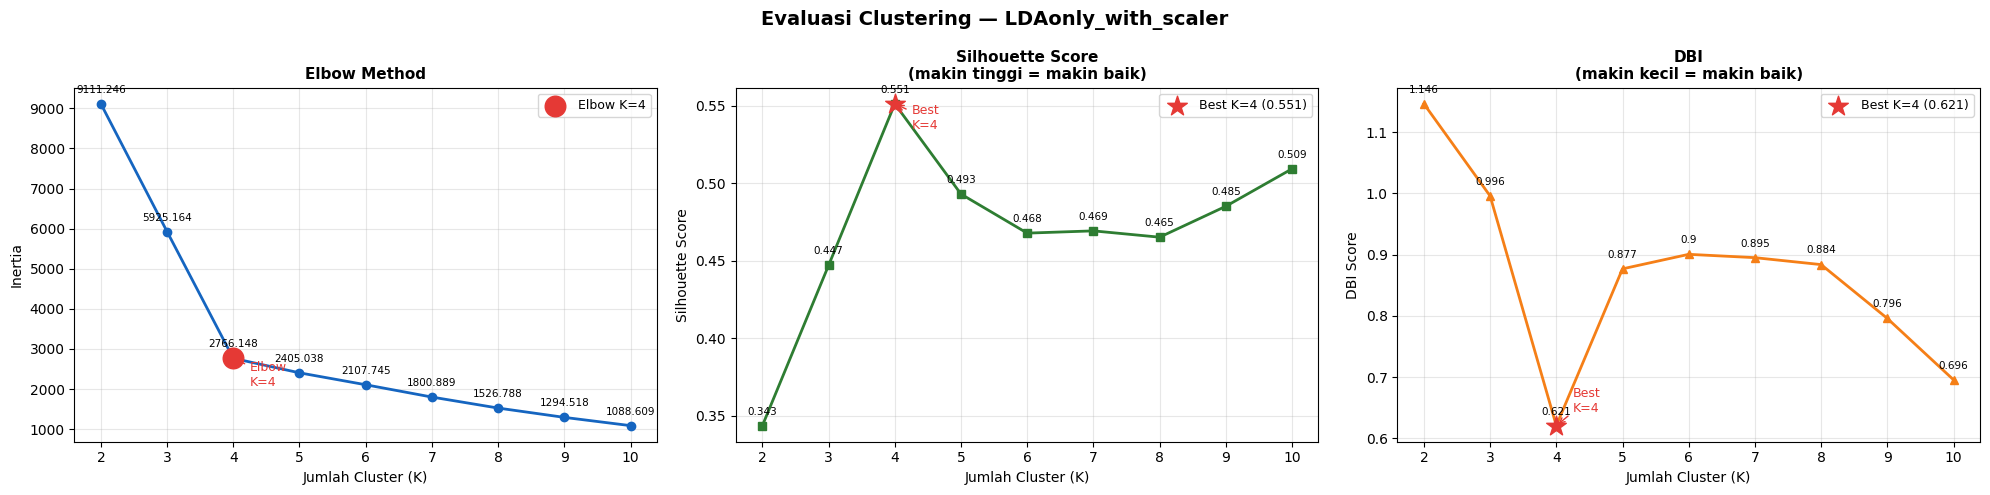

✔ Grafik evaluasi disimpan: hasil/lda_only/with_scaler/grafik/eval_LDAonly_with_scaler.png

--- NO_SCALER ---
✔ Semua metode sepakat: K=4 -> pakai SILHOUETTE


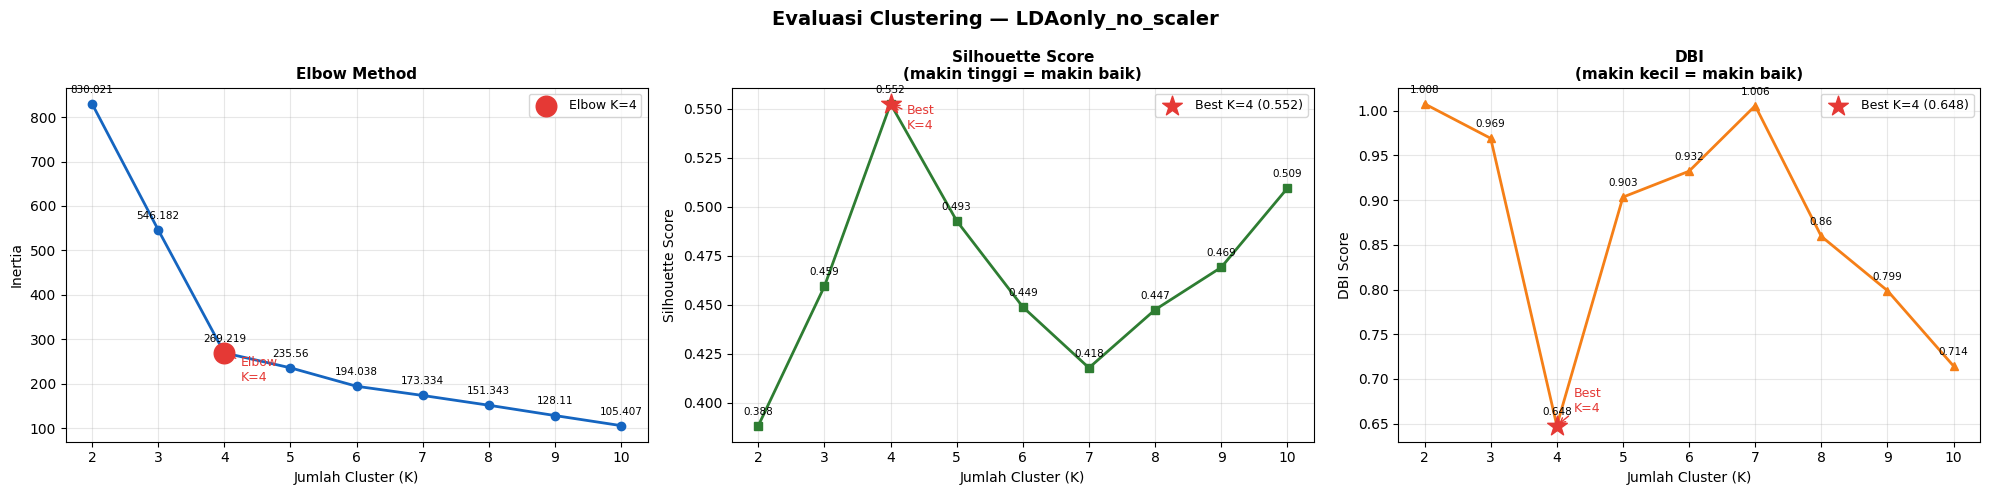

✔ Grafik evaluasi disimpan: hasil/lda_only/no_scaler/grafik/eval_LDAonly_no_scaler.png


In [12]:
final_k_per_skenario = {}

for skenario, hasil in hasil_pencarian_k.items():
    print(f"\n--- {skenario.upper()} ---")
    final_k_per_skenario[skenario] = decide_final_k(hasil["best"])

    plot_evaluation(
        hasil["k_list"], hasil["sil_list"], hasil["dbi_list"], hasil["inertia_list"],
        hasil["best"], scenario_name=f"LDAonly_{skenario}",
        save_dir=os.path.join(FOLDERS[skenario], "grafik")
    )

## 6. Clustering Final per Metode (Silhouette, Elbow, DBI) — Kedua Skenario

Untuk setiap kombinasi **skenario fitur** (`with_scaler` / `no_scaler`) dan **metode pemilihan k** (Silhouette, Elbow, DBI), K-Means dijalankan ulang dengan k terpilih, lalu dianalisis: visualisasi cluster, kata kunci dominan (c-TF-IDF), Coherence Score, dan Silhouette per cluster.

Seluruh gambar (`.png`) dan tabel (Excel) disimpan ke folder masing-masing skenario (`hasil/lda_only/with_scaler/` dan `hasil/lda_only/no_scaler/`) agar struktur folder rapi saat diunggah ke GitHub.



#################################################################
#  SKENARIO: WITH_SCALER
#################################################################

────────────────────────────────────────────────────────────
  METODE: Silhouette  |  K=4
────────────────────────────────────────────────────────────
✔ 2D plot disimpan: hasil/lda_only/with_scaler/grafik/2d_LDAonly_with_scaler_Silhouette_k4.png


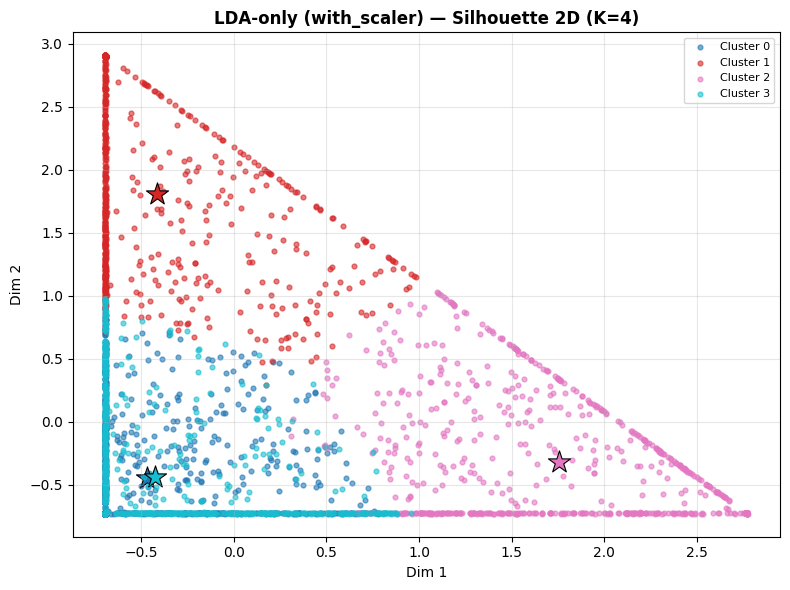

✔ 3D static plot disimpan: hasil/lda_only/with_scaler/grafik/3d_LDAonly_with_scaler_Silhouette_k4.png


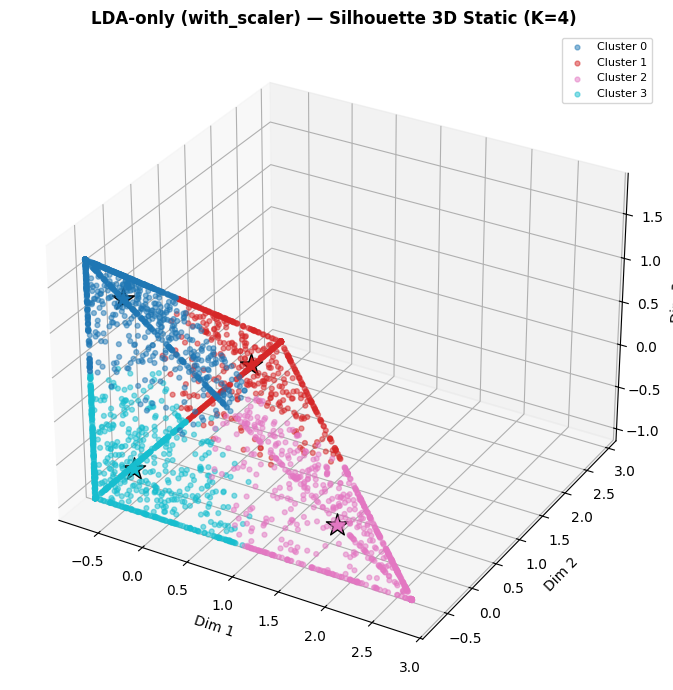

  ▶ 3D Interaktif Silhouette K=4



Keywords (Silhouette):


,cluster_id,keyword,ctfidf
0,0,feature,0.296
1,0,algorithm,0.291
2,0,accuracy,0.263
3,0,classification,0.256
4,0,selection,0.245
5,0,dimensionality,0.181
6,0,reduction,0.168
7,0,technique,0.154
8,0,model,0.154
9,0,machine_learning,0.139


  Coherence Score (Silhouette): 0.589

Silhouette per cluster (Silhouette):


,cluster_id,silhouette_per_cluster,jumlah_dokumen,persentase,cluster_label,coherence_score
0,0,0.627,1135,34.125,Cluster_0,0.589
1,1,0.470,615,18.491,Cluster_1,0.589
2,2,0.504,669,20.114,Cluster_2,0.589
3,3,0.546,907,27.270,Cluster_3,0.589



Pivot Label Topik x Cluster (Silhouette):


,label_topik,Cluster_0,Cluster_1,Cluster_2,Cluster_3
0,Feature Selection ML,1135,32,27,15
1,Forecasting Time Series,0,0,634,1
2,Predictive Analytics,0,574,1,0
3,Sentiment Media Sosial,0,9,7,891



────────────────────────────────────────────────────────────
  METODE: Elbow  |  K=4
────────────────────────────────────────────────────────────
✔ 2D plot disimpan: hasil/lda_only/with_scaler/grafik/2d_LDAonly_with_scaler_Elbow_k4.png


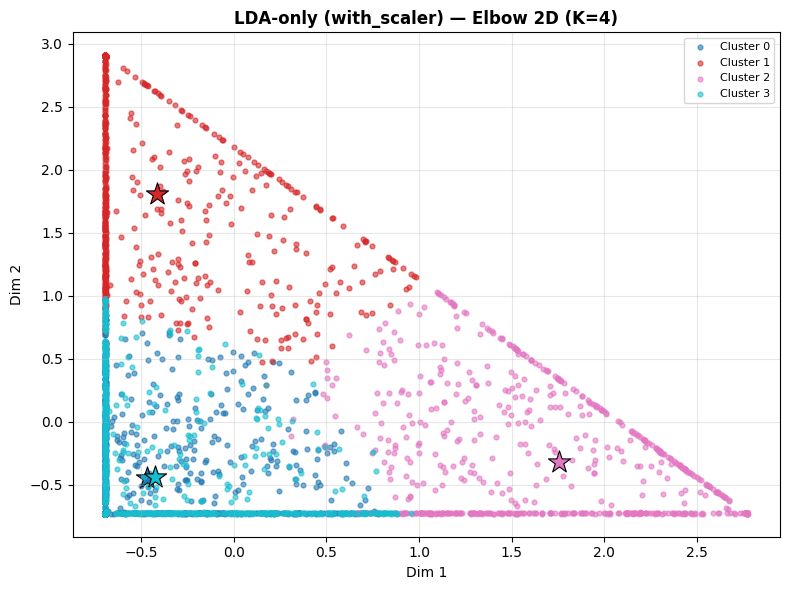

✔ 3D static plot disimpan: hasil/lda_only/with_scaler/grafik/3d_LDAonly_with_scaler_Elbow_k4.png


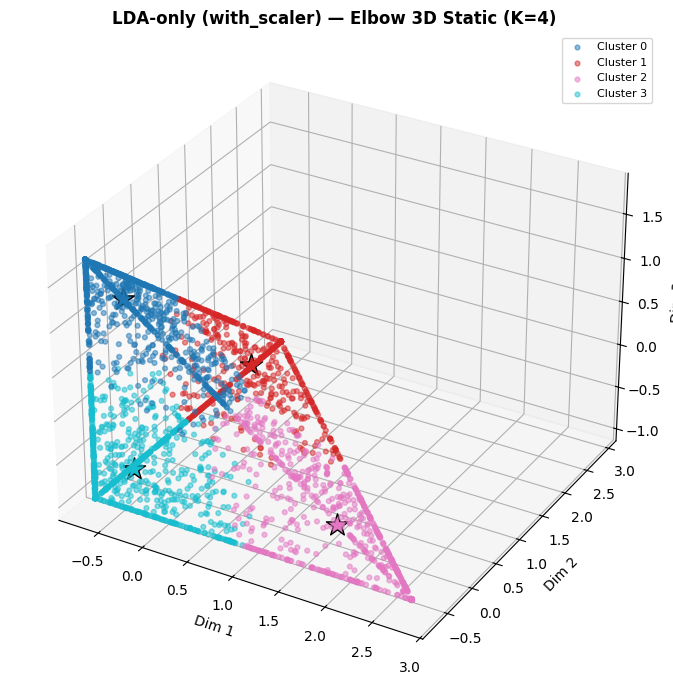

  ▶ 3D Interaktif Elbow K=4



Keywords (Elbow):


,cluster_id,keyword,ctfidf
0,0,feature,0.296
1,0,algorithm,0.291
2,0,accuracy,0.263
3,0,classification,0.256
4,0,selection,0.245
5,0,dimensionality,0.181
6,0,reduction,0.168
7,0,technique,0.154
8,0,model,0.154
9,0,machine_learning,0.139


  Coherence Score (Elbow): 0.589

Silhouette per cluster (Elbow):


,cluster_id,silhouette_per_cluster,jumlah_dokumen,persentase,cluster_label,coherence_score
0,0,0.627,1135,34.125,Cluster_0,0.589
1,1,0.470,615,18.491,Cluster_1,0.589
2,2,0.504,669,20.114,Cluster_2,0.589
3,3,0.546,907,27.270,Cluster_3,0.589



Pivot Label Topik x Cluster (Elbow):


,label_topik,Cluster_0,Cluster_1,Cluster_2,Cluster_3
0,Feature Selection ML,1135,32,27,15
1,Forecasting Time Series,0,0,634,1
2,Predictive Analytics,0,574,1,0
3,Sentiment Media Sosial,0,9,7,891



────────────────────────────────────────────────────────────
  METODE: DBI  |  K=4
────────────────────────────────────────────────────────────
✔ 2D plot disimpan: hasil/lda_only/with_scaler/grafik/2d_LDAonly_with_scaler_DBI_k4.png


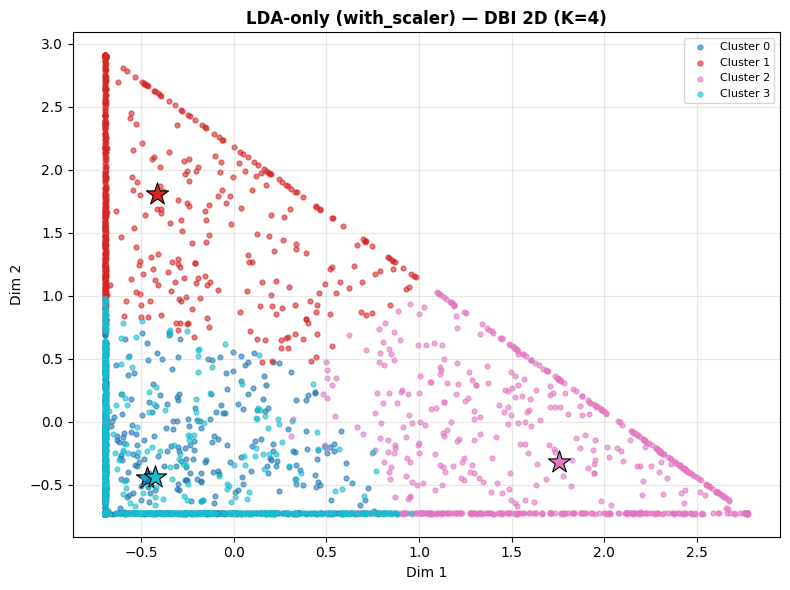

✔ 3D static plot disimpan: hasil/lda_only/with_scaler/grafik/3d_LDAonly_with_scaler_DBI_k4.png


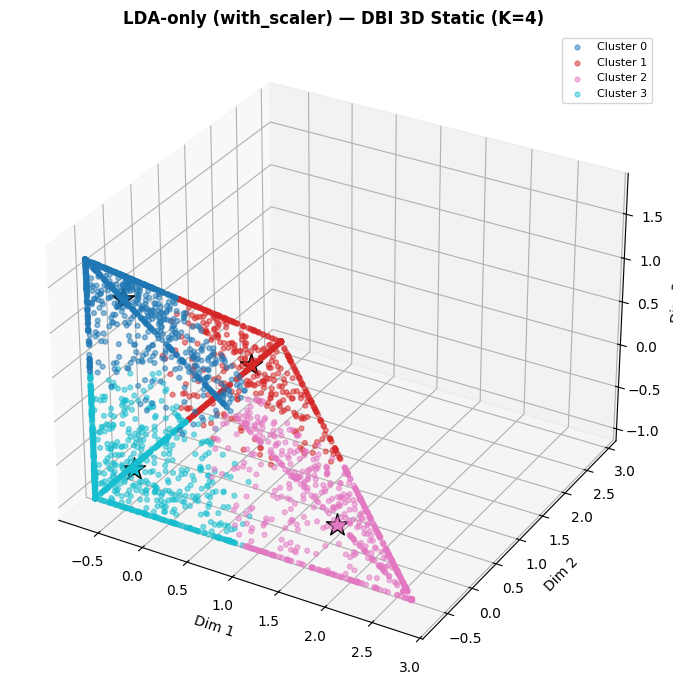

  ▶ 3D Interaktif DBI K=4



Keywords (DBI):


,cluster_id,keyword,ctfidf
0,0,feature,0.296
1,0,algorithm,0.291
2,0,accuracy,0.263
3,0,classification,0.256
4,0,selection,0.245
5,0,dimensionality,0.181
6,0,reduction,0.168
7,0,technique,0.154
8,0,model,0.154
9,0,machine_learning,0.139


  Coherence Score (DBI): 0.589

Silhouette per cluster (DBI):


,cluster_id,silhouette_per_cluster,jumlah_dokumen,persentase,cluster_label,coherence_score
0,0,0.627,1135,34.125,Cluster_0,0.589
1,1,0.470,615,18.491,Cluster_1,0.589
2,2,0.504,669,20.114,Cluster_2,0.589
3,3,0.546,907,27.270,Cluster_3,0.589



Pivot Label Topik x Cluster (DBI):


,label_topik,Cluster_0,Cluster_1,Cluster_2,Cluster_3
0,Feature Selection ML,1135,32,27,15
1,Forecasting Time Series,0,0,634,1
2,Predictive Analytics,0,574,1,0
3,Sentiment Media Sosial,0,9,7,891


✔ Excel disimpan: hasil/lda_only/with_scaler/HASIL_LDAonly_with_scaler.xlsx

#################################################################
#  SKENARIO: NO_SCALER
#################################################################

────────────────────────────────────────────────────────────
  METODE: Silhouette  |  K=4
────────────────────────────────────────────────────────────
✔ 2D plot disimpan: hasil/lda_only/no_scaler/grafik/2d_LDAonly_no_scaler_Silhouette_k4.png


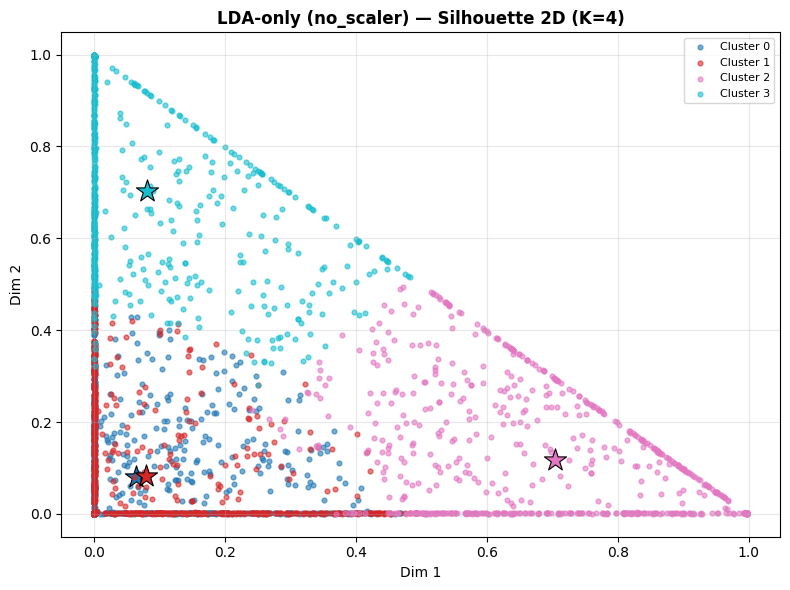

✔ 3D static plot disimpan: hasil/lda_only/no_scaler/grafik/3d_LDAonly_no_scaler_Silhouette_k4.png


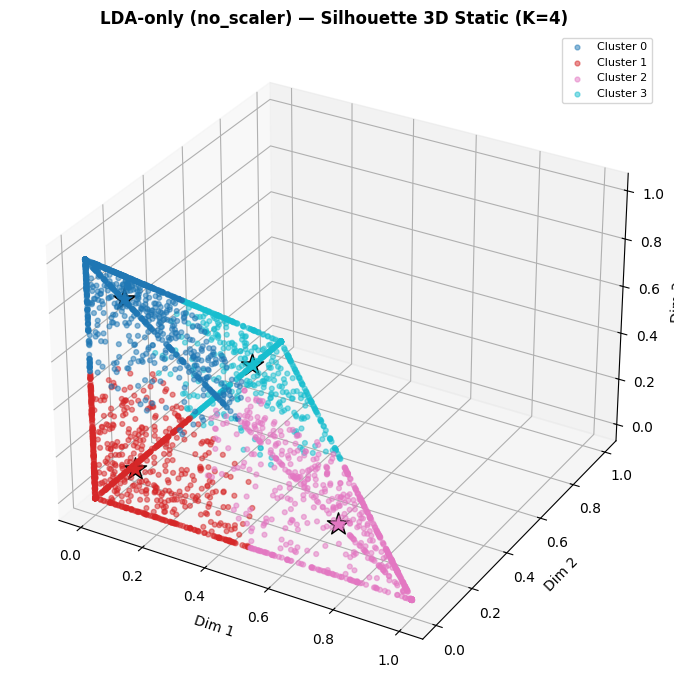

  ▶ 3D Interaktif Silhouette K=4



Keywords (Silhouette):


,cluster_id,keyword,ctfidf
0,0,feature,0.296
1,0,algorithm,0.288
2,0,accuracy,0.262
3,0,classification,0.255
4,0,selection,0.245
5,0,dimensionality,0.180
6,0,reduction,0.167
7,0,model,0.157
8,0,technique,0.155
9,0,machine_learning,0.141


  Coherence Score (Silhouette): 0.589

Silhouette per cluster (Silhouette):


,cluster_id,silhouette_per_cluster,jumlah_dokumen,persentase,cluster_label,coherence_score
0,0,0.635,1142,34.336,Cluster_0,0.589
1,1,0.547,917,27.571,Cluster_1,0.589
2,2,0.497,669,20.114,Cluster_2,0.589
3,3,0.465,598,17.980,Cluster_3,0.589



Pivot Label Topik x Cluster (Silhouette):


,label_topik,Cluster_0,Cluster_1,Cluster_2,Cluster_3
0,Feature Selection ML,1142,13,29,25
1,Forecasting Time Series,0,0,635,0
2,Predictive Analytics,0,0,4,571
3,Sentiment Media Sosial,0,904,1,2



────────────────────────────────────────────────────────────
  METODE: Elbow  |  K=4
────────────────────────────────────────────────────────────
✔ 2D plot disimpan: hasil/lda_only/no_scaler/grafik/2d_LDAonly_no_scaler_Elbow_k4.png


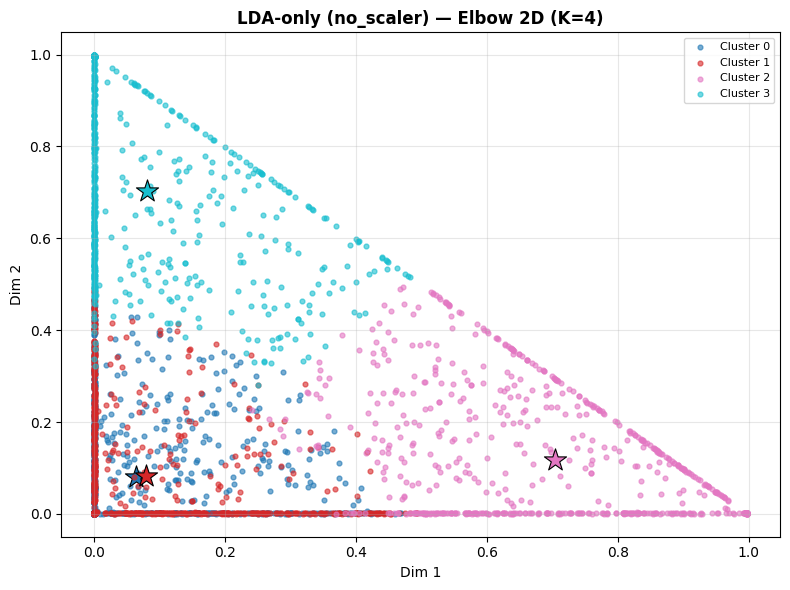

✔ 3D static plot disimpan: hasil/lda_only/no_scaler/grafik/3d_LDAonly_no_scaler_Elbow_k4.png


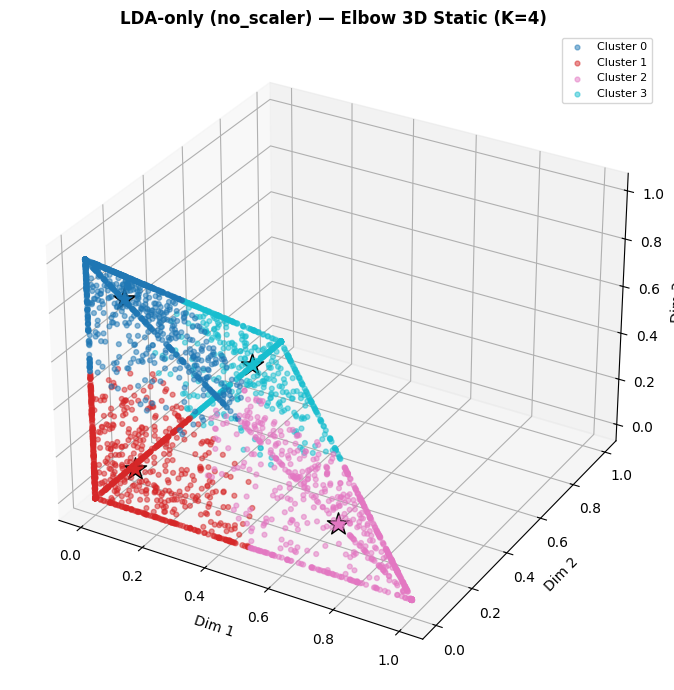

  ▶ 3D Interaktif Elbow K=4



Keywords (Elbow):


,cluster_id,keyword,ctfidf
0,0,feature,0.296
1,0,algorithm,0.288
2,0,accuracy,0.262
3,0,classification,0.255
4,0,selection,0.245
5,0,dimensionality,0.180
6,0,reduction,0.167
7,0,model,0.157
8,0,technique,0.155
9,0,machine_learning,0.141


  Coherence Score (Elbow): 0.589

Silhouette per cluster (Elbow):


,cluster_id,silhouette_per_cluster,jumlah_dokumen,persentase,cluster_label,coherence_score
0,0,0.635,1142,34.336,Cluster_0,0.589
1,1,0.547,917,27.571,Cluster_1,0.589
2,2,0.497,669,20.114,Cluster_2,0.589
3,3,0.465,598,17.980,Cluster_3,0.589



Pivot Label Topik x Cluster (Elbow):


,label_topik,Cluster_0,Cluster_1,Cluster_2,Cluster_3
0,Feature Selection ML,1142,13,29,25
1,Forecasting Time Series,0,0,635,0
2,Predictive Analytics,0,0,4,571
3,Sentiment Media Sosial,0,904,1,2



────────────────────────────────────────────────────────────
  METODE: DBI  |  K=4
────────────────────────────────────────────────────────────
✔ 2D plot disimpan: hasil/lda_only/no_scaler/grafik/2d_LDAonly_no_scaler_DBI_k4.png


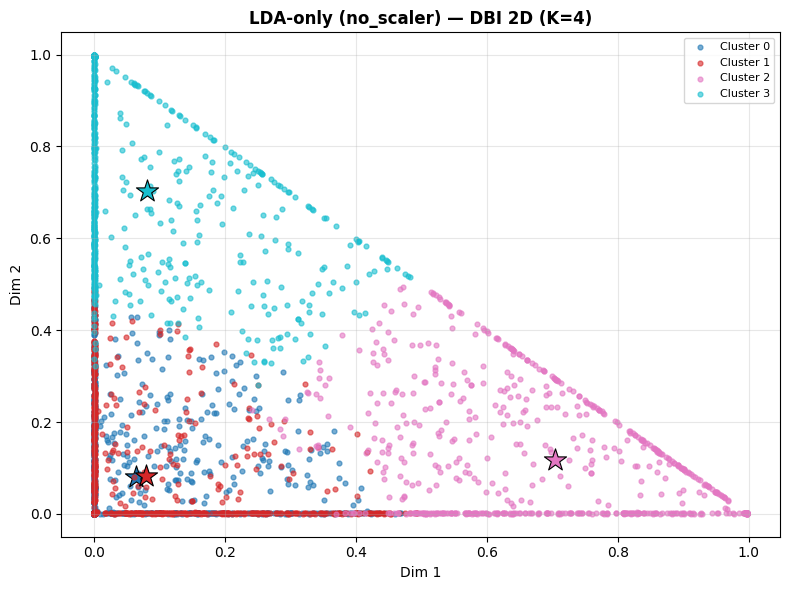

✔ 3D static plot disimpan: hasil/lda_only/no_scaler/grafik/3d_LDAonly_no_scaler_DBI_k4.png


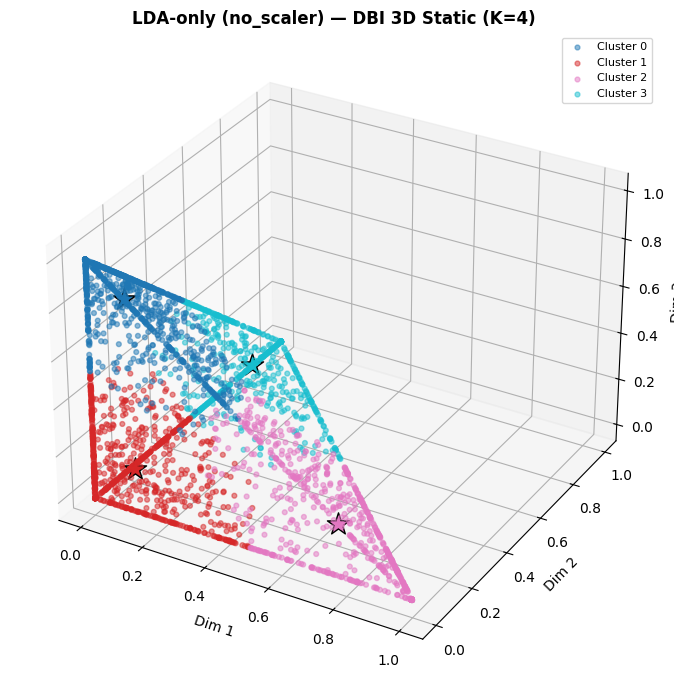

  ▶ 3D Interaktif DBI K=4



Keywords (DBI):


,cluster_id,keyword,ctfidf
0,0,feature,0.296
1,0,algorithm,0.288
2,0,accuracy,0.262
3,0,classification,0.255
4,0,selection,0.245
5,0,dimensionality,0.180
6,0,reduction,0.167
7,0,model,0.157
8,0,technique,0.155
9,0,machine_learning,0.141


  Coherence Score (DBI): 0.589

Silhouette per cluster (DBI):


,cluster_id,silhouette_per_cluster,jumlah_dokumen,persentase,cluster_label,coherence_score
0,0,0.635,1142,34.336,Cluster_0,0.589
1,1,0.547,917,27.571,Cluster_1,0.589
2,2,0.497,669,20.114,Cluster_2,0.589
3,3,0.465,598,17.980,Cluster_3,0.589



Pivot Label Topik x Cluster (DBI):


,label_topik,Cluster_0,Cluster_1,Cluster_2,Cluster_3
0,Feature Selection ML,1142,13,29,25
1,Forecasting Time Series,0,0,635,0
2,Predictive Analytics,0,0,4,571
3,Sentiment Media Sosial,0,904,1,2


✔ Excel disimpan: hasil/lda_only/no_scaler/HASIL_LDAonly_no_scaler.xlsx


In [13]:
artefak = {}   # artefak[skenario][metode] = {...}

for skenario, X in DATASETS.items():
    print(f"\n{'#' * 65}")
    print(f"#  SKENARIO: {skenario.upper()}")
    print(f"{'#' * 65}")

    metode_k = {
        "Silhouette": final_k_per_skenario[skenario]["sil"],
        "Elbow": final_k_per_skenario[skenario]["elbow"],
        "DBI": final_k_per_skenario[skenario]["dbi"],
    }

    artefak[skenario] = {}
    sheets = {}
    grafik_dir = os.path.join(FOLDERS[skenario], "grafik")

    for metode, k in metode_k.items():
        print(f"\n{'─' * 60}")
        print(f"  METODE: {metode}  |  K={k}")
        print(f"{'─' * 60}")

        labels, centroids = cluster_with_k(X, k)
        df_clus = df.copy()
        df_clus["cluster"] = labels

        tag = f"LDAonly_{skenario}_{metode}_k{k}"

        # Visualisasi 2D
        save_2d = os.path.join(grafik_dir, f"2d_{tag}.png")
        plot_cluster_2d(X[:, :2], labels, centroids[:, :2],
                         title=f"LDA-only ({skenario}) — {metode} 2D (K={k})", save_path=save_2d)

        # Visualisasi 3D statis
        save_3d = os.path.join(grafik_dir, f"3d_{tag}.png")
        plot_cluster_3d_static(X, labels, centroids,
                                title=f"LDA-only ({skenario}) — {metode} 3D Static (K={k})",
                                save_path=save_3d)

        # Visualisasi 3D interaktif
        print(f"  ▶ 3D Interaktif {metode} K={k}")
        plot_cluster_3d_interactive(X, labels, centroids,
                                     title=f"LDA-only ({skenario}) — {metode} 3D (K={k})")

        # c-TF-IDF (kata kunci dominan) -- pakai kolom string lemma_text
        df_kw = extract_ctfidf(df_clus, text_col="lemma_text", top_n=10)
        print(f"\nKeywords ({metode}):")
        display(df_kw)

        # Coherence Score -- pakai kolom list token lemma_tokens
        coh = compute_coherence(df_clus, df_kw, token_col="lemma_tokens")
        print(f"  Coherence Score ({metode}): {coh}")

        # Silhouette per cluster
        df_sil_cl = silhouette_per_cluster(X, labels)
        df_sil_cl["cluster_label"] = df_sil_cl["cluster_id"].apply(lambda x: f"Cluster_{x}")
        df_sil_cl["coherence_score"] = coh
        print(f"\nSilhouette per cluster ({metode}):")
        display(df_sil_cl)

        df_ring = df_sil_cl[
            ["cluster_id", "cluster_label", "jumlah_dokumen", "silhouette_per_cluster", "persentase"]
        ].copy()

        # Pivot label_topik x cluster
        if "label_topik" in df_clus.columns:
            df_pivot = build_pivot(df_clus, label_col="label_topik")
            print(f"\nPivot Label Topik x Cluster ({metode}):")
            display(df_pivot)
        else:
            df_pivot = pd.DataFrame()

        artefak[skenario][metode] = {
            "df_cluster": df_clus, "df_keywords": df_kw,
            "df_ringkasan": df_ring, "df_pivot": df_pivot,
            "coherence": coh, "k": k,
            "sil_score": float(np.mean(df_sil_cl["silhouette_per_cluster"])),
        }

        sheets[f"{metode}_Dataset"] = df_clus.drop(columns=["lemma_tokens"], errors="ignore")
        sheets[f"{metode}_Keywords"] = df_kw
        sheets[f"{metode}_Ringkasan"] = df_ring
        if not df_pivot.empty:
            sheets[f"{metode}_Pivot"] = df_pivot

    excel_path = os.path.join(FOLDERS[skenario], f"HASIL_LDAonly_{skenario}.xlsx")
    save_excel(excel_path, sheets)

## 7. Perbandingan Akhir: Dengan Scaler vs Tanpa Scaler

Tabel ini membandingkan **Silhouette Score, DBI, dan Coherence Score** dari kedua skenario (`with_scaler` dan `no_scaler`), pada metode terbaik masing-masing (Silhouette), untuk menjawab secara empiris apakah `StandardScaler` memberi pengaruh berarti saat fitur clustering hanya berasal dari distribusi topik LDA.


In [14]:
rows_compare = []
for skenario in DATASETS:
    info = artefak[skenario]["Silhouette"]
    k = info["k"]
    hasil = hasil_pencarian_k[skenario]
    idx_k = hasil["k_list"].index(k)

    rows_compare.append({
        "skenario": skenario,
        "k_terpilih": k,
        "silhouette_score": round(hasil["sil_list"][idx_k], ROUND_DIGIT),
        "dbi_score": round(hasil["dbi_list"][idx_k], ROUND_DIGIT),
        "coherence_score": info["coherence"],
    })

df_compare_scaler = pd.DataFrame(rows_compare).sort_values("silhouette_score", ascending=False).reset_index(drop=True)

print("PERBANDINGAN: DENGAN SCALER vs TANPA SCALER (metode Silhouette)")
display(df_compare_scaler)

compare_path = os.path.join(BASE_DIR, "perbandingan_scaler_vs_noscaler.xlsx")
save_excel(compare_path, {"Perbandingan": df_compare_scaler})

PERBANDINGAN: DENGAN SCALER vs TANPA SCALER (metode Silhouette)


,skenario,k_terpilih,silhouette_score,dbi_score,coherence_score
0,no_scaler,4,0.552,0.648,0.589
1,with_scaler,4,0.551,0.621,0.589


✔ Excel disimpan: hasil/lda_only/perbandingan_scaler_vs_noscaler.xlsx


### 7.1 Interpretasi Perbandingan

Jika kedua baris pada tabel di atas menunjukkan **k optimal dan skor evaluasi yang hampir identik**, ini mengonfirmasi bahwa `StandardScaler` tidak banyak berpengaruh pada skenario ini — sesuai ekspektasi, karena seluruh fitur (probabilitas topik LDA) sudah berada pada skala yang sama (0–1) sejak awal, sehingga standarisasi tidak mengoreksi disparitas skala seperti pada kasus penggabungan fitur embedding + LDA.

Jika hasilnya **berbeda cukup jauh**, itu berarti standarisasi tetap memengaruhi bentuk ruang fitur (misalnya karena distribusi tiap topik tidak seragam variansnya), dan skenario mana yang dipakai final sebaiknya ditentukan berdasarkan Silhouette Score tertinggi pada tabel ini.


## 8. Ringkasan File Output (Struktur Folder untuk GitHub)

Seluruh hasil notebook ini tersimpan dengan struktur folder berikut, siap diunggah ke GitHub:

```
hasil/
└── lda_only/
    ├── with_scaler/
    │   ├── grafik/
    │   │   ├── eval_LDAonly_with_scaler.png
    │   │   ├── 2d_LDAonly_with_scaler_Silhouette_k4.png
    │   │   ├── 3d_LDAonly_with_scaler_Silhouette_k4.png
    │   │   └── ... (untuk metode Elbow & DBI jika k berbeda)
    │   └── HASIL_LDAonly_with_scaler.xlsx
    ├── no_scaler/
    │   ├── grafik/
    │   │   └── ... (sama seperti with_scaler)
    │   └── HASIL_LDAonly_no_scaler.xlsx
    └── perbandingan_scaler_vs_noscaler.xlsx
```

Sel berikut menampilkan daftar lengkap seluruh file yang berhasil disimpan, untuk verifikasi sebelum di-`git add` / `git commit` / `git push`.


In [15]:
print(f"Struktur folder akhir di dalam '{BASE_DIR}':\n")

for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

Struktur folder akhir di dalam 'hasil/lda_only':

lda_only/
  perbandingan_scaler_vs_noscaler.xlsx
  no_scaler/
    HASIL_LDAonly_no_scaler.xlsx
    grafik/
      2d_LDAonly_no_scaler_DBI_k4.png
      2d_LDAonly_no_scaler_Elbow_k4.png
      2d_LDAonly_no_scaler_Silhouette_k4.png
      3d_LDAonly_no_scaler_DBI_k4.png
      3d_LDAonly_no_scaler_Elbow_k4.png
      3d_LDAonly_no_scaler_Silhouette_k4.png
      eval_LDAonly_no_scaler.png
  with_scaler/
    HASIL_LDAonly_with_scaler.xlsx
    grafik/
      2d_LDAonly_with_scaler_DBI_k4.png
      2d_LDAonly_with_scaler_Elbow_k4.png
      2d_LDAonly_with_scaler_Silhouette_k4.png
      3d_LDAonly_with_scaler_DBI_k4.png
      3d_LDAonly_with_scaler_Elbow_k4.png
      3d_LDAonly_with_scaler_Silhouette_k4.png
      eval_LDAonly_with_scaler.png
